##### Modeling and Forecasting

This section develops and evaluates ARIMA-based forecasting models for the daily aggregate electricity demand series. Based on the exploratory data analysis, the original series is non-stationary and first-order differencing is required. Therefore, the modeling process focuses on comparing several ARIMA specifications with \(d = 1\), evaluating them using both information criteria and out-of-sample forecast accuracy.

The modeling section is divided into:

1. Model selection  
2. Model estimation  
3. Model diagnostics  
4. Model evaluation  
5. Forecasting  

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# Path to the dataset
file_path = Path("../data/LD2011_2014.txt")

# Load full dataset
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    parse_dates=[0]
)

# Rename timestamp column and set index
df.rename(columns={df.columns[0]: "timestamp"}, inplace=True)
df.set_index("timestamp", inplace=True)

# Aggregate all smart meters and scale to MW
aggregate_demand = df.sum(axis=1) / 1e6
df_aggregate = aggregate_demand.to_frame(name="aggregate_demand_MW")

# Convert to daily aggregate demand
df_aggregate_daily = df_aggregate.resample("D").sum()

# Keep the stable period after the structural shift in active meters
df_model = df_aggregate_daily.loc["2012-01-01":"2014-12-30"].copy()

# Drop missing values if any
df_model = df_model.dropna()

print(df_model.shape)
df_model.head()

(1095, 1)


,aggregate_demand_MW
timestamp,
2012-01-01,12.259839
2012-01-02,18.210642
2012-01-03,18.229872
2012-01-04,18.296147
2012-01-05,18.347230


##### Modeling Dataset

The modeling stage uses the period from 2012 onward. The exploratory analysis showed that the number of active smart meters increased sharply between 2011 and 2012, producing a structural level shift in the aggregate demand series. To avoid biasing the model with this structural break, the forecasting models are estimated using the more stable period from 2012 to 2014.

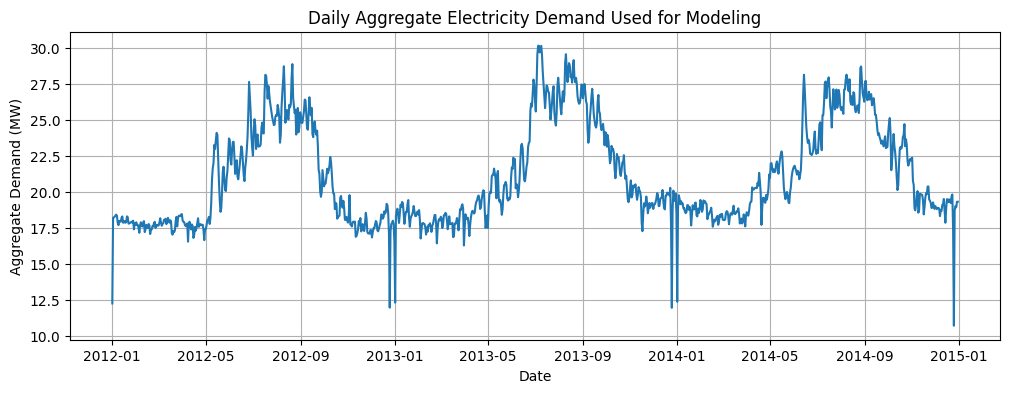

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(df_model.index, df_model["aggregate_demand_MW"])
plt.title("Daily Aggregate Electricity Demand Used for Modeling")
plt.xlabel("Date")
plt.ylabel("Aggregate Demand (MW)")
plt.grid(True)
plt.show()

##### Train-Test Split

To evaluate forecasting performance, the time series is split chronologically into a training set and a test set. The model is estimated using historical observations, and its forecasts are compared against the held-out test period. This avoids random shuffling, which would be inappropriate for time series data because temporal ordering must be preserved.

In [8]:
series = df_model["aggregate_demand_MW"]

# Use the last 90 days as test set
test_size = 90

train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())
print("Train size:", len(train))
print("Test size:", len(test))

Train period: 2012-01-01 00:00:00 to 2014-10-01 00:00:00
Test period: 2014-10-02 00:00:00 to 2014-12-30 00:00:00
Train size: 1005
Test size: 90


##### Model Selection

The exploratory analysis suggested that the original series is non-stationary, while the first-differenced series is stationary. Therefore, all candidate ARIMA models use \(d = 1\). The ACF of the differenced series suggested a possible MA component, while the PACF suggested a low-order AR component. Based on this interpretation, the following candidate models are compared:

- ARIMA(1,1,0)
- ARIMA(0,1,1)
- ARIMA(1,1,1)
- ARIMA(2,1,1)
- ARIMA(1,1,2)

Models are compared using AIC and out-of-sample forecast accuracy.

In [9]:
candidate_orders = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
]

results = []

for order in candidate_orders:
    try:
        model = ARIMA(train, order=order)
        fitted_model = model.fit()
        
        forecast = fitted_model.forecast(steps=len(test))
        
        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))
        mape = np.mean(np.abs((test - forecast) / test)) * 100
        
        results.append({
            "Model": f"ARIMA{order}",
            "Order": order,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE (%)": mape
        })
        
    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="RMSE")

comparison_df

,Model,Order,AIC,BIC,MAE,RMSE,MAPE (%)
3,"ARIMA(2, 1, 1)","(2, 1, 1)",2501.646556,2521.293545,3.490306,4.025799,18.555321
4,"ARIMA(1, 1, 2)","(1, 1, 2)",2496.877147,2516.524136,3.514840,4.049924,18.680527
2,"ARIMA(1, 1, 1)","(1, 1, 1)",2527.737263,2542.472505,3.646588,4.177077,19.349717
0,"ARIMA(1, 1, 0)","(1, 1, 0)",2573.274475,2583.097969,3.816446,4.337556,20.208302
1,"ARIMA(0, 1, 1)","(0, 1, 1)",2573.236255,2583.059749,3.821673,4.342422,20.234649


##### Selected Model

The final model is selected based on a combination of statistical fit and forecasting performance. AIC and BIC evaluate in-sample model fit while penalizing excessive complexity, whereas MAE, RMSE, and MAPE evaluate out-of-sample forecast accuracy. The preferred model is the one that provides strong predictive performance while remaining relatively simple and interpretable.

In [10]:
best_row = comparison_df.iloc[0]
best_order = best_row["Order"]

print("Best model based on RMSE:")
print(best_row)

best_order

Best model based on RMSE:
Model       ARIMA(2, 1, 1)
Order            (2, 1, 1)
AIC            2501.646556
BIC            2521.293545
MAE               3.490306
RMSE              4.025799
MAPE (%)         18.555321
Name: 3, dtype: object


(2, 1, 1)

##### Model Estimation

After selecting the best-performing specification, the model is estimated on the training set. The estimated coefficients describe the temporal dependence structure of the series after differencing. The AR terms capture dependence on past values, while the MA terms capture dependence on past forecast errors.

In [11]:
best_model = ARIMA(train, order=best_order)
best_fitted = best_model.fit()

print(best_fitted.summary())

                                SARIMAX Results                                
Dep. Variable:     aggregate_demand_MW   No. Observations:                 1005
Model:                  ARIMA(2, 1, 1)   Log Likelihood               -1246.823
Date:                 Tue, 28 Apr 2026   AIC                           2501.647
Time:                         11:34:07   BIC                           2521.294
Sample:                     01-01-2012   HQIC                          2509.112
                          - 10-01-2014                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7100      0.051     13.871      0.000       0.610       0.810
ar.L2         -0.1933      0.033     -5.815      0.000      -0.258      -0.128
ma.L1         -0.7596      0.055    -13.865 

##### Forecast on the Test Set

The selected model is used to generate forecasts over the test period. These forecasts are then compared against the actual observed values to evaluate out-of-sample predictive performance.

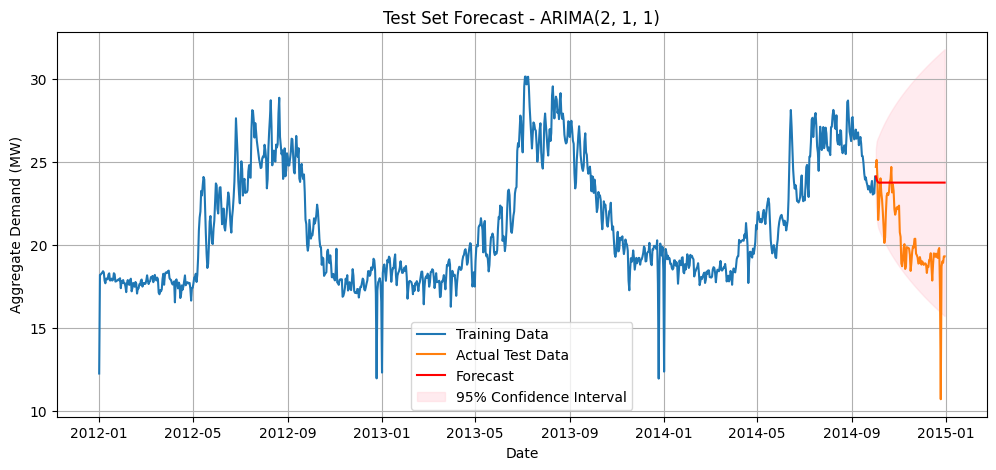

In [12]:
test_forecast_result = best_fitted.get_forecast(steps=len(test))
test_forecast = test_forecast_result.predicted_mean
test_conf_int = test_forecast_result.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, test_forecast, label="Forecast", color="red")

plt.fill_between(
    test.index,
    test_conf_int.iloc[:, 0],
    test_conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title(f"Test Set Forecast - ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Aggregate Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

##### Model Evaluation

Forecasting accuracy is evaluated using MAE, RMSE, and MAPE. MAE measures the average absolute forecast error, RMSE penalizes larger errors more heavily, and MAPE expresses the average error as a percentage of actual demand.

In [13]:
mae = mean_absolute_error(test, test_forecast)
rmse = np.sqrt(mean_squared_error(test, test_forecast))
mape = np.mean(np.abs((test - test_forecast) / test)) * 100

evaluation_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE (%)"],
    "Value": [mae, rmse, mape]
})

evaluation_metrics

,Metric,Value
0,MAE,3.490306
1,RMSE,4.025799
2,MAPE (%),18.555321


##### Residual Diagnostics

A good time series model should capture the systematic structure in the data. After fitting the model, the residuals should behave approximately like white noise: they should be centered around zero, show no clear pattern over time, and exhibit little or no autocorrelation. Residual diagnostics are therefore essential to determine whether the model has successfully captured the main temporal dependencies.

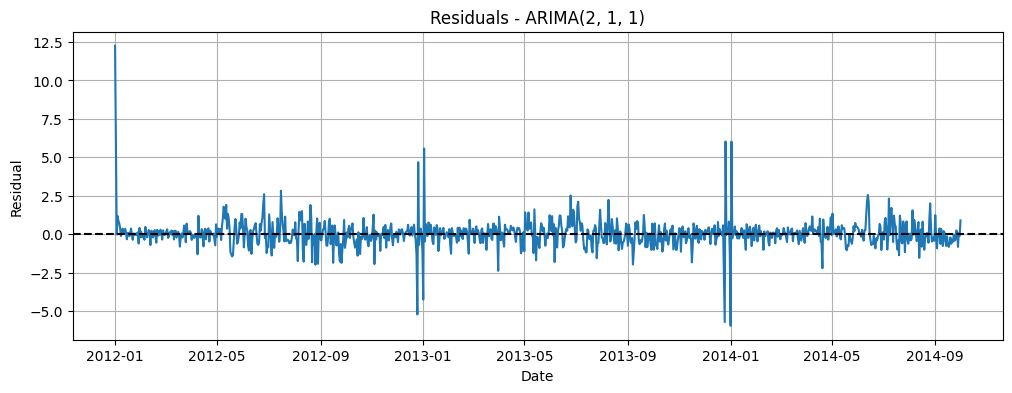

In [14]:
residuals = best_fitted.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.axhline(0, color="black", linestyle="--")
plt.title(f"Residuals - ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

##### Residual ACF

The residual ACF is used to check whether significant autocorrelation remains after model fitting. If most autocorrelations fall within the confidence bands, the residuals are approximately uncorrelated, suggesting that the model has captured the main time dependence in the data.

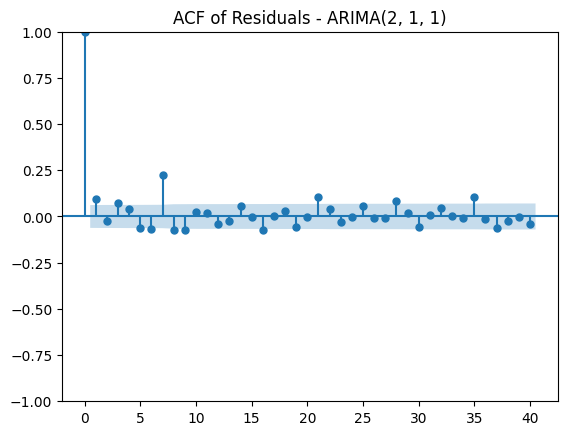

In [15]:
plot_acf(residuals.dropna(), lags=40)
plt.title(f"ACF of Residuals - ARIMA{best_order}")
plt.show()

##### Ljung-Box Test

The Ljung-Box test provides a formal statistical check for residual autocorrelation. The null hypothesis is that the residuals are independently distributed, meaning that no significant autocorrelation remains. A p-value above 0.05 suggests that the residuals are consistent with white noise.

In [16]:
ljung_box_results = acorr_ljungbox(
    residuals.dropna(),
    lags=[10, 20, 30],
    return_df=True
)

ljung_box_results

,lb_stat,lb_pvalue
10,88.153878,1.243238e-14
20,103.692605,2.734792e-13
30,131.721306,1.044896e-14


##### Final Model Refit

After selecting and evaluating the model, the final ARIMA specification is refitted using the full modeling dataset. This allows the final forecast to use all available information from the stable period.

In [17]:
final_model = ARIMA(series, order=best_order)
final_fitted = final_model.fit()

print(final_fitted.summary())

                                SARIMAX Results                                
Dep. Variable:     aggregate_demand_MW   No. Observations:                 1095
Model:                  ARIMA(2, 1, 1)   Log Likelihood               -1409.274
Date:                 Tue, 28 Apr 2026   AIC                           2826.547
Time:                         11:34:08   BIC                           2846.538
Sample:                     01-01-2012   HQIC                          2834.112
                          - 12-30-2014                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6733      0.049     13.870      0.000       0.578       0.768
ar.L2         -0.1738      0.034     -5.065      0.000      -0.241      -0.107
ma.L1         -0.7658      0.052    -14.679 

## Future Forecasting

The final model is used to forecast future aggregate electricity demand. The forecast includes point predictions and confidence intervals, which quantify the uncertainty associated with future values.

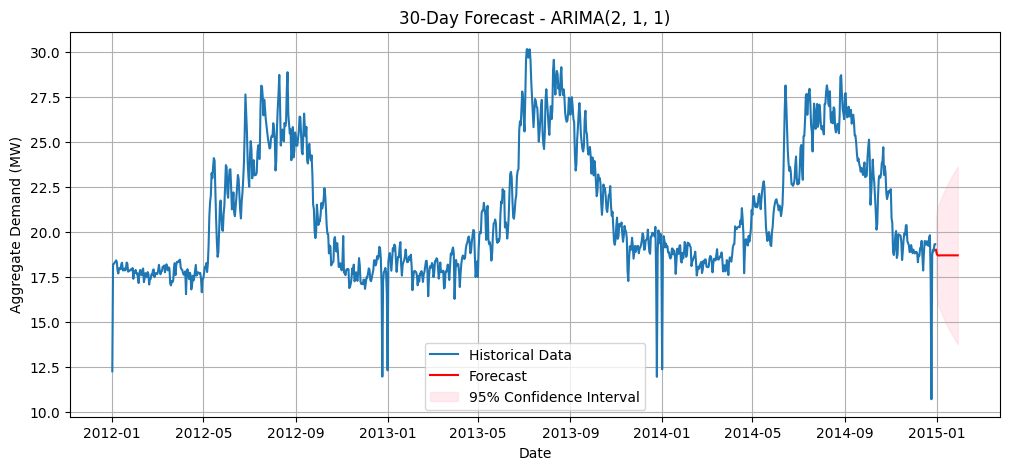

In [18]:
forecast_horizon = 30

future_forecast_result = final_fitted.get_forecast(steps=forecast_horizon)
future_forecast = future_forecast_result.predicted_mean
future_conf_int = future_forecast_result.conf_int()

future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=forecast_horizon,
    freq="D"
)

future_forecast.index = future_dates
future_conf_int.index = future_dates

plt.figure(figsize=(12, 5))
plt.plot(series.index, series, label="Historical Data")
plt.plot(future_forecast.index, future_forecast, label="Forecast", color="red")

plt.fill_between(
    future_conf_int.index,
    future_conf_int.iloc[:, 0],
    future_conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title(f"30-Day Forecast - ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Aggregate Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
forecast_table = pd.DataFrame({
    "forecast_MW": future_forecast,
    "lower_95": future_conf_int.iloc[:, 0],
    "upper_95": future_conf_int.iloc[:, 1]
})

forecast_table.head(10)

,forecast_MW,lower_95,upper_95
2014-12-31,19.017756,17.298247,20.737265
2015-01-01,18.809599,16.487523,21.131675
2015-01-02,18.723041,16.129709,21.316373
2015-01-03,18.700935,15.952889,21.448981
2015-01-04,18.701093,15.834968,21.567218
2015-01-05,18.705041,15.731232,21.678850
2015-01-06,18.707672,15.629371,21.785973
2015-01-07,18.708757,15.528098,21.889417
2015-01-08,18.709031,15.428448,21.989614
2015-01-09,18.709026,15.331192,22.086861


## Modeling Summary

The modeling process began by selecting candidate ARIMA models based on the EDA results. Since the original series was non-stationary and the first-differenced series was stationary, all candidate models used \(d = 1\). The ACF and PACF of the differenced series suggested the presence of both AR and MA components, motivating the comparison of several low-order ARIMA models.

The final model was selected based on out-of-sample forecasting accuracy and information criteria. Residual diagnostics were then used to verify whether the model captured the main temporal structure of the data. Finally, the selected model was refitted on the full stable dataset and used to generate future electricity demand forecasts.